# 03 — Conflict Detection

Applying FAA separation standards to detect horizontal and vertical separation violations across all aircraft pairs in each snapshot.

**FAA Standards Applied (7110.65):** https://www.faa.gov/air_traffic/publications/atpubs/ATC/atc0505.html
- Horizontal: < 3 NM (terminal) / < 5 NM (en route)
- Vertical: < 1,000 ft

## 1. Load & Reconstruct States

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from airspace import (AircraftState, detect_conflicts, conflicts_to_df,
                       conflict_risk_score, closing_speed_kts,
                       FAA_HORIZONTAL_SEP_NM, FAA_VERTICAL_SEP_FT)

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("../data/raw_states.csv", parse_dates=["time_utc"])
print(f"Loaded {len(df)} state vectors across {df['time'].nunique()} snapshots")

Loaded 872 state vectors across 5 snapshots


In [2]:
def row_to_state(row) -> AircraftState:
    return AircraftState(
        icao24=row["icao24"], callsign=row["callsign"],
        time=row["time"], lat=row["lat"], lon=row["lon"],
        altitude_ft=row["altitude_ft"], velocity_kts=row["velocity_kts"],
        heading_deg=row["heading_deg"], on_ground=bool(row["on_ground"]),
    )

# Group by snapshot timestamp, reconstruct AircraftState objects
snapshots = {
    t: [row_to_state(r) for _, r in grp.iterrows()]
    for t, grp in df.groupby("time")
}
print(f"Reconstructed {len(snapshots)} snapshots")
for t, states in snapshots.items():
    print(f"  t={t}  — {len(states)} aircraft")

Reconstructed 5 snapshots
  t=1773422210.0  — 145 aircraft
  t=1773422220.0  — 146 aircraft
  t=1773422256.0  — 145 aircraft
  t=1773422266.0  — 146 aircraft
  t=1773422274.0  — 290 aircraft


## 2. Run Pairwise Separation Checks

In [3]:
all_conflicts = []

for timestamp, states in snapshots.items():
    conflicts = detect_conflicts(
        states,
        horizontal_min_nm=FAA_HORIZONTAL_SEP_NM,
        vertical_min_ft=FAA_VERTICAL_SEP_FT
    )
    all_conflicts.extend(conflicts)

cdf = conflicts_to_df(all_conflicts)
print(f"Total conflict events detected: {len(cdf)}")
if len(cdf) > 0:
    print("\nSeverity breakdown:")
    print(cdf["severity"].value_counts())
cdf.head(10)

Total conflict events detected: 400

Severity breakdown:
severity
CRITICAL    199
ADVISORY    139
WARNING      62
Name: count, dtype: int64


,time,icao_a,icao_b,callsign_a,callsign_b,horizontal_dist_nm,vertical_dist_ft,severity,lat_midpoint,lon_midpoint
0,1.773422e+09,a3917e,a2ce8d,N329TX,N280FW,2.570,600.0,ADVISORY,32.84860,-97.34185
1,1.773422e+09,a45052,a49a5b,N3771L,N396PC,2.700,550.0,ADVISORY,32.48255,-96.87430
2,1.773422e+09,a45052,a04b96,N3771L,N118TB,2.637,400.0,ADVISORY,32.49860,-96.90410
3,1.773422e+09,a9af67,a20132,CXK533,N22808,0.858,875.0,ADVISORY,32.67345,-97.10425
4,1.773422e+09,aaa7b5,a2b885,N786KD,N2746C,1.267,525.0,WARNING,32.76815,-96.52980
5,1.773422e+09,aaf70f,a7299c,N8052A,N5602V,1.309,50.0,WARNING,33.10430,-96.07475
6,1.773422e+09,ad081a,a4ea9d,N939LH,N416CA,2.661,250.0,ADVISORY,32.64950,-96.82420
7,1.773422e+09,aa34d0,adb2bd,N757HY,N982BT,1.709,975.0,ADVISORY,33.38830,-97.33815
8,1.773422e+09,a7ea3f,ac9b48,N609SA,N911KE,1.577,500.0,WARNING,33.01095,-96.51215
9,1.773422e+09,a5bb0b,a12215,N469AA,N172RC,2.983,600.0,ADVISORY,33.23775,-97.42645


## 3. Risk Scoring

Assign each conflict a composite risk score [0-100] incorporating separation margin, severity, and closing speed.

In [4]:
if len(cdf) > 0:
    # Rebuild state lookups for closing speed calculation
    state_lookup = {s.icao24: s for states in snapshots.values() for s in states}

    risk_scores = []
    for _, row in cdf.iterrows():
        sa = state_lookup.get(row["icao_a"])
        sb = state_lookup.get(row["icao_b"])
        closing = closing_speed_kts(sa, sb) if (sa and sb) else None
        from airspace import ConflictEvent
        evt = ConflictEvent(**row.to_dict())
        risk_scores.append(conflict_risk_score(evt, closing))

    cdf["risk_score"]    = risk_scores
    cdf["closing_speed"] = [
        closing_speed_kts(state_lookup.get(r["icao_a"]),
                          state_lookup.get(r["icao_b"]))
        if (state_lookup.get(r["icao_a"]) and state_lookup.get(r["icao_b"])) else None
        for _, r in cdf.iterrows()
    ]

    print("Top 10 highest-risk conflicts:")
    print(cdf.nlargest(10, "risk_score")[
        ["callsign_a","callsign_b","horizontal_dist_nm",
         "vertical_dist_ft","severity","risk_score"]
    ])

Top 10 highest-risk conflicts:
    callsign_a callsign_b  horizontal_dist_nm  vertical_dist_ft  severity  \
14       SWA22     N581RS               0.005              25.0  CRITICAL   
37       SWA22     N581RS               0.005              25.0  CRITICAL   
115    ENY4095    ENY4095               0.000               0.0  CRITICAL   
116     N43408     N43408               0.000               0.0  CRITICAL   
117    SWA2531    SWA2531               0.000               0.0  CRITICAL   
119     N329TX     N329TX               0.000               0.0  CRITICAL   
121     N527PN     N527PN               0.000               0.0  CRITICAL   
122     N131PA     N131PA               0.000               0.0  CRITICAL   
123     N3914Q     N3914Q               0.000               0.0  CRITICAL   
124     N3771L     N3771L               0.000               0.0  CRITICAL   

     risk_score  
14        80.08  
37        80.08  
115       80.00  
116       80.00  
117       80.00  
119       80.

## 4. Visualize Conflict Distribution

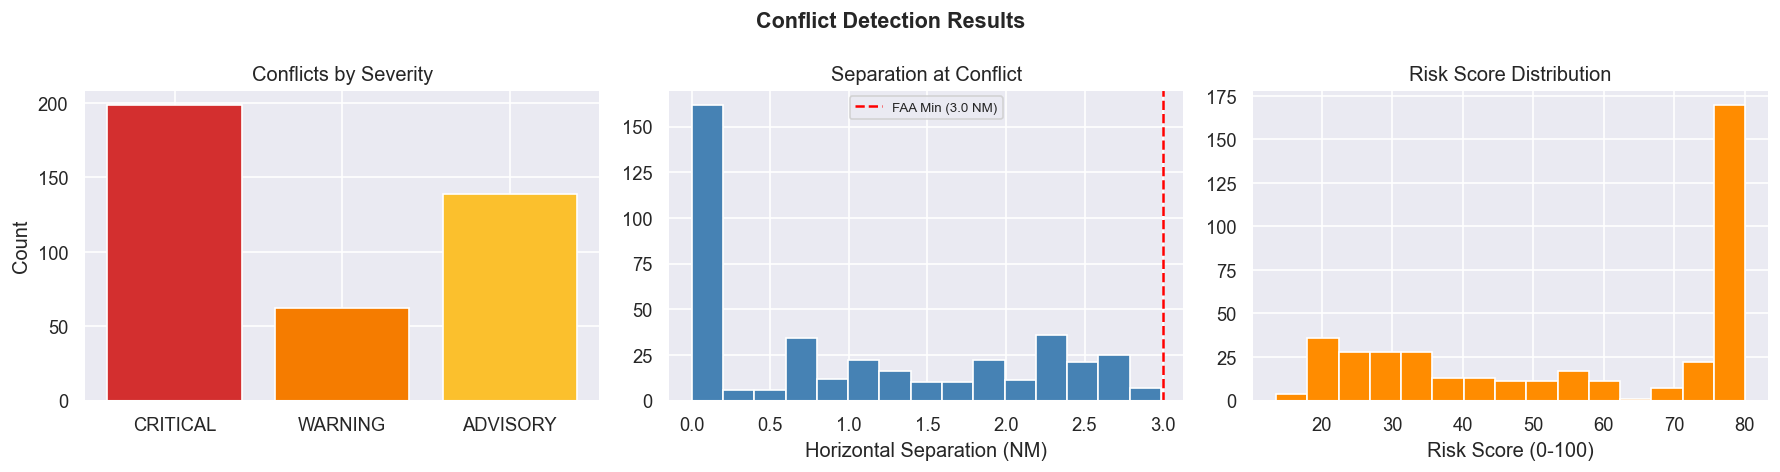

In [5]:
if len(cdf) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Severity counts
    sev_order = ["CRITICAL","WARNING","ADVISORY"]
    sev_colors = {"CRITICAL":"#d32f2f","WARNING":"#f57c00","ADVISORY":"#fbc02d"}
    sev_counts = cdf["severity"].value_counts().reindex(sev_order, fill_value=0)
    axes[0].bar(sev_counts.index,
                sev_counts.values,
                color=[sev_colors[s] for s in sev_counts.index],
                edgecolor="white")
    axes[0].set_title("Conflicts by Severity")
    axes[0].set_ylabel("Count")

    # Horizontal separation distribution
    axes[1].hist(cdf["horizontal_dist_nm"], bins=15, color="steelblue", edgecolor="white")
    axes[1].axvline(FAA_HORIZONTAL_SEP_NM, color="red", linestyle="--",
                    label=f"FAA Min ({FAA_HORIZONTAL_SEP_NM} NM)")
    axes[1].set_xlabel("Horizontal Separation (NM)")
    axes[1].set_title("Separation at Conflict")
    axes[1].legend(fontsize=8)

    # Risk score distribution
    axes[2].hist(cdf["risk_score"], bins=15, color="darkorange", edgecolor="white")
    axes[2].set_xlabel("Risk Score (0-100)")
    axes[2].set_title("Risk Score Distribution")

    plt.suptitle("Conflict Detection Results", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("../outputs/03_conflicts.png", bbox_inches="tight")
    plt.show()
else:
    print("No conflicts detected in this dataset. Try increasing N_SNAPSHOTS in notebook 01.")

## 5. Save Conflict Data

In [6]:
os.makedirs("../data", exist_ok=True)
if len(cdf) > 0:
    cdf.to_csv("../data/conflicts.csv", index=False)
    print(f"Saved {len(cdf)} conflict events -> ../data/conflicts.csv")
else:
    # Write empty file so downstream notebooks don't break
    cdf.to_csv("../data/conflicts.csv", index=False)
    print("No conflicts to save — empty CSV written.")

Saved 400 conflict events -> ../data/conflicts.csv
